In [1]:
# 코드 6-1 : 필요한 라이브러리 호출

!pip install --user tqdm
import torch
import torchvision
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms # 이미지 변환(전처리) 기능을 제공하는 라이브러리
from torch.autograd import Variable
from torch import optim # 경사하강법을 활용하여 가중치를 구하기 위한 옵티마이저 라이브러리
import torch.nn as nn
import torch.nn.functional as F
import os # 파일 경로에 대한 함수들을 제공
import cv2
from PIL import Image
from tqdm import tqdm_notebook as tqdm # 진행 상황을 가시적으로 표현 - 모델의 학습 경과를 확인하고 싶을 때 사용하는 라이브러리
import random
from matplotlib import pyplot as plt


device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [2]:
# 코드 6-2 : 이미지 데이터셋 전처리

class ImageTransform():
    def __init__(self, resize, mean, std):
        self.data_transform = {
            'train': transforms.Compose([
                transforms.RandomResizedCrop(resize, scale=(0.5, 1.0)), # 입력 이미지를 주어진 크기로 조정
                transforms.RandomHorizontalFlip(), # 주어진 확률로 이미지를 수평 반전
                transforms.ToTensor(), # torch.FloatTensor 배열로 바꾸어 주는 메서드
                transforms.Normalize(mean, std) # 입력 데이터 정규화 : 데이터의 스케일을 줄이고 0 근처 분포로 만들어 학습을 잘 되게 도움
            ]),
            'val': transforms.Compose([
                transforms.Resize(256),
                transforms.CenterCrop(resize),
                transforms.ToTensor(),
                transforms.Normalize(mean, std)
            ])
        }

    def __call__(self, img, phase):
        return self.data_transform[phase](img)

In [3]:
from google.colab import files # 데이터 불러오기
file_uploaded=files.upload()   # chap06/data/dogs-vs-cats.zip 데이터 불러오기

Saving dogs-vs-cats.zip to dogs-vs-cats.zip


In [4]:
!unzip dogs-vs-cats.zip -d dogs-vs-cats/  #dogs-vs-cats 폴더 만들어 압축 풀기

Archive:  dogs-vs-cats.zip
   creating: dogs-vs-cats/Cat/
  inflating: dogs-vs-cats/Cat/cat.0.jpg  
  inflating: dogs-vs-cats/Cat/cat.1.jpg  
  inflating: dogs-vs-cats/Cat/cat.10.jpg  
  inflating: dogs-vs-cats/Cat/cat.100.jpg  
  inflating: dogs-vs-cats/Cat/cat.101.jpg  
  inflating: dogs-vs-cats/Cat/cat.102.jpg  
  inflating: dogs-vs-cats/Cat/cat.103.jpg  
  inflating: dogs-vs-cats/Cat/cat.104.jpg  
  inflating: dogs-vs-cats/Cat/cat.105.jpg  
  inflating: dogs-vs-cats/Cat/cat.106.jpg  
  inflating: dogs-vs-cats/Cat/cat.107.jpg  
  inflating: dogs-vs-cats/Cat/cat.108.jpg  
  inflating: dogs-vs-cats/Cat/cat.109.jpg  
  inflating: dogs-vs-cats/Cat/cat.11.jpg  
  inflating: dogs-vs-cats/Cat/cat.110.jpg  
  inflating: dogs-vs-cats/Cat/cat.111.jpg  
  inflating: dogs-vs-cats/Cat/cat.112.jpg  
  inflating: dogs-vs-cats/Cat/cat.113.jpg  
  inflating: dogs-vs-cats/Cat/cat.114.jpg  
  inflating: dogs-vs-cats/Cat/cat.115.jpg  
  inflating: dogs-vs-cats/Cat/cat.116.jpg  
  inflating: dogs-vs-cat

In [5]:
# 코드 6-3 : 이미지 데이터셋을 불러온 후 훈련, 검증, 테스트로 분리

cat_directory = 'dogs-vs-cats/Cat/'
dog_directory = 'dogs-vs-cats/Dog/'

cat_images_filepaths = sorted([os.path.join(cat_directory, f) for f in os.listdir(cat_directory)])
# sorted : 데이터를 정렬된 리스트로 만들어서 반환
# os.path.join : 경로와 파일명을 결합 or 분할된 경로를 하나로 합치고 싶을 때 사용
# os.listdir : 지정한 디렉터리 내 모든 파일의 리스트 반환
dog_images_filepaths = sorted([os.path.join(dog_directory, f) for f in os.listdir(dog_directory)])
images_filepaths = [*cat_images_filepaths, *dog_images_filepaths]
correct_images_filepaths = [i for i in images_filepaths if cv2.imread(i) is not None]

random.seed(42)
random.shuffle(correct_images_filepaths)
train_images_filepaths = correct_images_filepaths[:400] # 훈련용 400개 이미지
val_images_filepaths = correct_images_filepaths[400:-10] # 검증용 92개 이미지
test_images_filepaths = correct_images_filepaths[-10:] # 테스트용 10개 이미지
print(len(train_images_filepaths), len(val_images_filepaths), len(test_images_filepaths))

400 92 10


In [6]:
# 코드 6-4 : 테스트 데이터셋 이미지 확인 검수

def display_image_grid(images_filepaths, predicted_labels=(), cols=5):
    rows = len(images_filepaths) // cols
    figure, ax = plt.subplots(nrows=rows, ncols=cols, figsize=(12, 6))
    for i, image_filepath in enumerate(images_filepaths):
        image = cv2.imread(image_filepath)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) # 이미지의 색상 변경 : BGR -> RGB
        true_label = os.path.normpath(image_filepath).split(os.sep)[-2] # 경로명 정규화
        predicted_label = predicted_labels[i] if predicted_labels else true_label
        color = "green" if true_label == predicted_label else "red" # 예측과 정답이 동일 - 초록색, 아니라면 빨간색
        ax.ravel()[i].imshow(image)
        ax.ravel()[i].set_title(predicted_label, color=color)
        ax.ravel()[i].set_axis_off() # 이미지의 축 제거
    plt.tight_layout() # 이미지의 여백 조정
    plt.show()

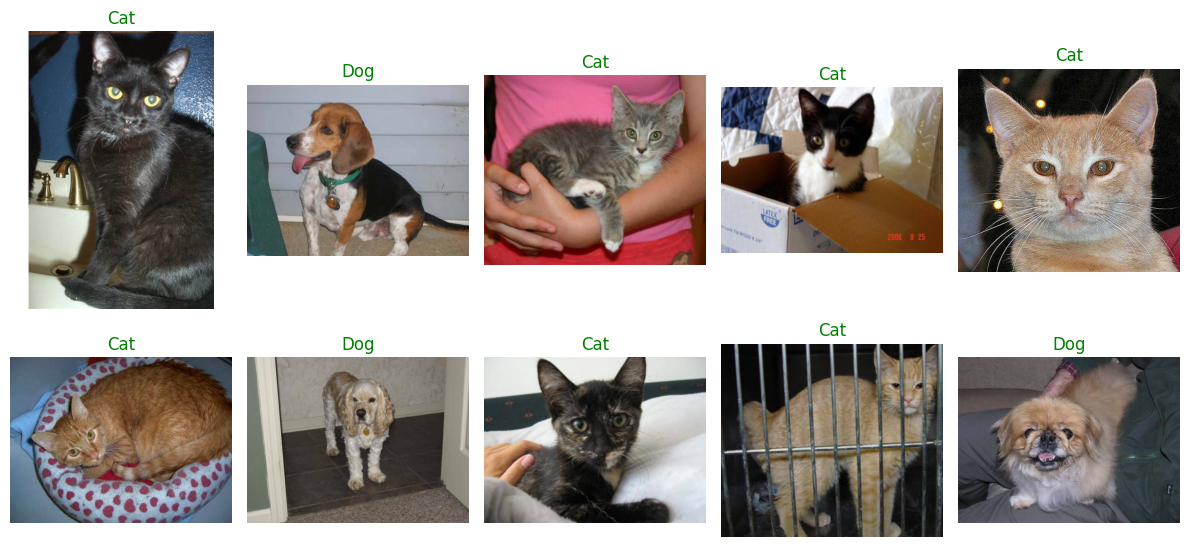

In [7]:
# 코드 6-5 : 테스트 데이터셋 이미지 출력

display_image_grid(test_images_filepaths)

In [8]:
# 코드 6-6 : 이미지 데이터셋 클래스 정의

class DogvsCatDataset(Dataset):
    def __init__(self, file_list, transform=None, phase='train'): # 데이터셋의 전처리
        self.file_list = file_list
        self.transform = transform
        self.phase = phase

    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx):
        img_path = self.file_list[idx]
        img = Image.open(img_path) # img_path 위치에서 이미지 데이터들을 가져옴
        img_transformed = self.transform(img, self.phase) # 이미지에 'train' 전처리를 적용

        label = img_path.split('/')[-1].split('.')[0] # / 와 . 를 제거, 분리된 값에서 index 0를 가져옴
        if label == 'dog':
            label = 1
        elif label == 'cat':
            label = 0
        return img_transformed, label

In [9]:
# 코드 6-7 : 변수 값 정의

size = 224
mean = (0.485, 0.456, 0.406)
std = (0.229, 0.224, 0.225)
batch_size = 32

In [10]:
# 코드 6-8 : 이미지 데이터셋 정의

train_dataset = DogvsCatDataset(train_images_filepaths, transform=ImageTransform(size, mean, std), phase='train')
# 훈련 데이터에 train_transforms을 적용
val_dataset = DogvsCatDataset(val_images_filepaths, transform=ImageTransform(size, mean, std), phase='val')
# 검증 이미지에 train_transforms을 적용

index = 0 # 첫번째 이미지 지정 (맨 첫번째 데이터 하나만 꺼내옴)
print(train_dataset.__getitem__(index)[0].size()) # 훈련 데이터의 크기 출력
print(train_dataset.__getitem__(index)[1]) # 훈련 데이터의 레이블 출력

torch.Size([3, 224, 224])
0


In [11]:
# 코드 6-9 : 데이터로더 정의

train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True) # 앞 코드 6-7에서 설정한 배치 사이즈(32)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False) # 데이터를 조금씩 쪼개어 가져옴
dataloader_dict = {'train': train_dataloader, 'val': val_dataloader}
# 훈련 데이터셋과 검증 데이터셋을 합쳐서 표현

batch_iterator = iter(train_dataloader)
inputs, label = next(batch_iterator)
print(inputs.size())
print(label)

torch.Size([32, 3, 224, 224])
tensor([0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0,
        1, 1, 1, 1, 1, 1, 1, 0])


In [13]:
# 코드 6-10 : 모델의 네트워크 플러스

class LeNet(nn.Module):
    def __init__(self):
        super(LeNet, self).__init__()
        self.cnn1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=5, stride=1, padding=0) #2d 합성곱층 적용
        self.relu1 = nn.ReLU() # 활성화 함수
        self.maxpool1 = nn.MaxPool2d(kernel_size=2) # 최대 풀링 적용
        self.cnn2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=5, stride=1, padding=0) #2d 합성곱층 적용
        self.relu2 = nn.ReLU() # 활성화 함수
        self.maxpool2 = nn.MaxPool2d(kernel_size=2) # 최대 풀링 적용
        self.fc1 = nn.Linear(32*53*53, 512) # 완전 연결층
        self.relu5 = nn.ReLU() # 활성화 함수
        self.fc2 = nn.Linear(512, 2) # 완전 연결층 : 최종 출력 노드 수를 2로 설정 - 고양이 / 개 판단
        self.output = nn.Softmax(dim=1) # 최종 출력값을 2개 클래스에 대한 확률 값으로 변환

    def forward(self, x):
        out = self.cnn1(x)
        out = self.relu1(out)
        out = self.maxpool1(out)
        out = self.cnn2(out)
        out = self.relu2(out)
        out = self.maxpool2(out)
        out = out.view(out.size(0), -1)
        out = self.fc1(out)
        out = self.fc2(out)
        out = self.output(out)
        return out

In [14]:
# 코드 6-11 : 모델 객체 생성

model = LeNet().to(device)
print(model)

LeNet(
  (cnn1): Conv2d(3, 16, kernel_size=(5, 5), stride=(1, 1))
  (relu1): ReLU()
  (maxpool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (cnn2): Conv2d(16, 32, kernel_size=(5, 5), stride=(1, 1))
  (relu2): ReLU()
  (maxpool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=89888, out_features=512, bias=True)
  (relu5): ReLU()
  (fc2): Linear(in_features=512, out_features=2, bias=True)
  (output): Softmax(dim=1)
)


In [15]:
# 코드 6-12 : torchsummary 라이브러리를 이용한 모델의 네트워크 구조 확인

!pip install torchsummary
from torchsummary import summary
summary(model, (3, 224, 224))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 16, 220, 220]           1,216
              ReLU-2         [-1, 16, 220, 220]               0
         MaxPool2d-3         [-1, 16, 110, 110]               0
            Conv2d-4         [-1, 32, 106, 106]          12,832
              ReLU-5         [-1, 32, 106, 106]               0
         MaxPool2d-6           [-1, 32, 53, 53]               0
            Linear-7                  [-1, 512]      46,023,168
            Linear-8                    [-1, 2]           1,026
           Softmax-9                    [-1, 2]               0
Total params: 46,038,242
Trainable params: 46,038,242
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.57
Forward/backward pass size (MB): 19.47
Params size (MB): 175.62
Estimated Total Size (MB): 195.67
--------------------------------

In [16]:
# 코드 6-13 : 학습 가능한 파라미터 수 확인

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'The model has {count_parameters(model):,} trainable parameters')

The model has 46,038,242 trainable parameters


In [17]:
# 코드 6-14 : 옵티마이저와 손실 함수 정의

optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9) # 경사 하강법 - 모멘텀 SGD 사용
criterion = nn.CrossEntropyLoss() # 손실함수 정의

In [18]:
# 코드 6-15 : 모델의 파라미터와 손실 함수를 CPU에 할당
# GPU를 활성화하지 않은 상태 - CPU 사용

model = model.to(device)
criterion = criterion.to(device)

In [19]:
# 코드 6-16 : 모델 학습 함수 정의

def train_model(model, dataloader_dict, criterion, optimizer, num_epoch):
    since = time.time()
    best_acc = 0.0

    for epoch in range(num_epoch):
        print('Epoch {}/{}'.format(epoch + 1, num_epoch))
        print('-'*20)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train() # 모델을 학습시키겠다는 의미
            else:
                model.eval()

            epoch_loss = 0.0
            epoch_corrects = 0

            for inputs, labels in tqdm(dataloader_dict[phase]):
                inputs = inputs.to(device) # 훈련 데이터셋을 CPU에 할당
                labels = labels.to(device)
                optimizer.zero_grad() # 역전파 실행 전 기울기를 0으로 초기화

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels) # loss 계산

                    if phase == 'train':
                        loss.backward() # 학습 가능한 파라미터에 대해 기울기 계산
                        optimizer.step() # 파라미터 갱신

                    epoch_loss += loss.item() * inputs.size(0) # 오차와 입력을 곱함
                    epoch_corrects += torch.sum(preds == labels.data) # 예측과 정답이 일치하면 epoch_corrects에 저장

            epoch_loss = epoch_loss / len(dataloader_dict[phase].dataset) # 최종 오차 계산
            epoch_acc = epoch_corrects.double() / len(dataloader_dict[phase].dataset) # 최종 정확도 계산

            print('{} Loss: {:.4f} Acc: {:.4f}'.format(phase, epoch_loss, epoch_acc))

            if phase == 'val' and epoch_acc > best_acc: # 검증 데이터셋에 대한 가장 최적의 정확도를 저장
                best_acc = epoch_acc
                best_model_wts = model.state_dict()

    time_elapsed = time.time() - since
    print('Training complete in {:.0f}m {:.0f}s'.format(
        time_elapsed // 60, time_elapsed % 60))
    print('Best val Acc: {:4f}'.format(best_acc))
    return model

In [20]:
# 코드 6-17 : 모델 학습

import time

num_epoch = 10
model = train_model(model, dataloader_dict, criterion, optimizer, num_epoch)

Epoch 1/10
--------------------


/tmp/ipykernel_2613/2910685612.py:20: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for inputs, labels in tqdm(dataloader_dict[phase]):


  0%|          | 0/13 [00:00<?, ?it/s]

train Loss: 0.6921 Acc: 0.5100


  0%|          | 0/3 [00:00<?, ?it/s]

...

val Loss: 0.7019 Acc: 0.5217
Epoch 10/10
--------------------


  0%|          | 0/13 [00:00<?, ?it/s]

train Loss: 0.6628 Acc: 0.6050


  0%|          | 0/3 [00:00<?, ?it/s]

val Loss: 0.6931 Acc: 0.5435
Training complete in 5m 57s
Best val Acc: 0.554348


In [21]:
# 코드 6-18 : 모델 테스트를 위한 함수 정의

import pandas as pd

id_list = []
pred_list = []
_id=0
with torch.no_grad(): # 역전파 중 텐서들에 대한 변화도를 계산할 필요가 없음 -> 훈련 모델과의 가장 큰 차이점
    for test_path in tqdm(test_images_filepaths): # 테스트 데이터셋 이용
        img = Image.open(test_path)
        _id =test_path.split('/')[-1].split('.')[1]
        transform = ImageTransform(size, mean, std)
        img = transform(img, phase='val') # 테스트 데이터셋 전처리 적용
        img = img.unsqueeze(0) # 텐서에 차원 추가, 0 : 차원이 추가될 위치
        img = img.to(device)

        model.eval()
        outputs = model(img)
        preds = F.softmax(outputs, dim=1)[:, 1].tolist() # 텐서의 요소가 (0,1) 범위에 있고 합계가 1이 되도록 크기 조정
        id_list.append(_id)
        pred_list.append(preds[0])

res = pd.DataFrame({
    'id': id_list,
    'label': pred_list
}) # 테스트 데이터셋의 예측 결과인 id와 label을 데이터 프레임에 저장

res.sort_values(by='id', inplace=True)
res.reset_index(drop=True, inplace=True)

res.to_csv('LesNet.csv', index=False) # 데이터 프레임을 csv 파일로 저장

/tmp/ipykernel_2613/2969246298.py:9: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for test_path in tqdm(test_images_filepaths): # 테스트 데이터셋 이용


  0%|          | 0/10 [00:00<?, ?it/s]

In [22]:
# 코드 6-19 : 테스트 데이터셋의 예측 결과 호출

res.head(10)

,id,label
0,109,0.514580
1,145,0.409990
2,15,0.608952
3,162,0.536567
4,167,0.523500
5,200,0.498173
6,210,0.630094
7,211,0.581465
8,213,0.418457
9,224,0.597991


In [23]:
# 코드 6-20 : 테스트 데이터셋 이미지를 출력하기 위한 함수 정의

class_ = classes = {0:'cat', 1:'dog'} # 개와 고양이에 대한 클래스 정의
def display_image_grid(images_filepaths, predicted_labels=(), cols=5):
    rows = len(images_filepaths) // cols
    figure, ax = plt.subplots(nrows=rows, ncols=cols, figsize=(12, 6))
    for i, image_filepath in enumerate(images_filepaths):
        image = cv2.imread(image_filepath)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        a = random.choice(res['id'].values)
        label = res.loc[res['id'] == a, 'label'].values[0]
        if label > 0.5:# 레이블 값이 0.5보다 크다면 개
            label = 1
        else: # 작다면 고양이
            label = 0
        ax.ravel()[i].imshow(image)
        ax.ravel()[i].set_title(class_[label])
        ax.ravel()[i].set_axis_off()
    plt.tight_layout()
    plt.show()

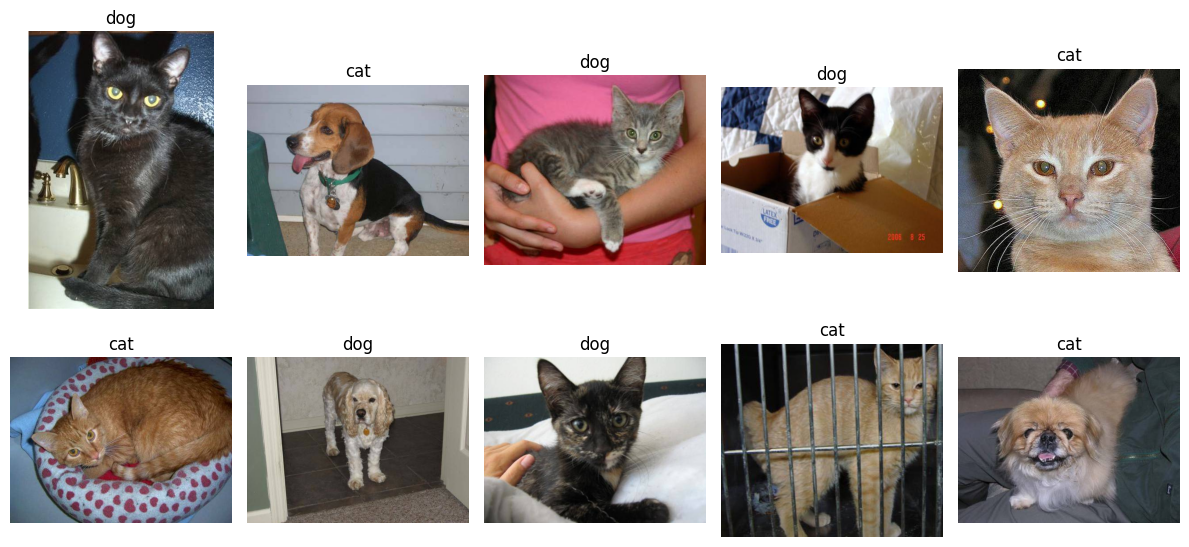

In [24]:
# 코드 6-21 : 테스트 데이터셋 예측 결과 이미지 출력

display_image_grid(test_images_filepaths)